# Mexican E-Commerce Platform: Customer Purchase Analysis

**Course:** Regression Analysis
**Students:** 
**Methods:** Multiple linear regression and two-way ANOVA
**Dataset:** `plataforma_ecommerce_mx.csv` (280 customers, one purchase each)
**Decision level:** α = 0.05 for every test in this notebook

This notebook answers two questions for the same dataset.

1. **Regression.** Which factors predict how much a customer spends, and can we predict spending for a new customer?
2. **ANOVA.** Do customer groups really spend different amounts, or is the gap only random variation?

Operations can use the regression to choose which customer traits to act on. Marketing and the regional teams can use the ANOVA to decide where a difference between groups is real.

## 1. Company and variables description (6%)

### Company and business context

The company is a Mexican e-commerce platform. Customers browse the site and then place an order. The commercial teams need to know **what drives the amount of a single purchase**, in Mexican pesos (MXN).

Two teams will use this analysis:

- **Operations** wants the factors that predict ticket size, and a check of whether a model can estimate spending for a new customer.
- **Marketing and the regional teams** want to know whether gaps between regions, genders, devices, or traffic sources are real. A real gap can justify a budget change. A gap that is only noise should not.

The platform sells four interest categories (Clothing, Electronics, Home, Sports). Customers arrive from four traffic sources (Search, Social, Email, Direct), on three devices (Mobile, Desktop, Tablet), and from four regions (Center, North, West, South). Each row in the file is one customer and one purchase.

### Variables

| Variable | Type | Role | Meaning |
|---|---|---|---|
| `id_cliente` | Integer identifier | Not a predictor | Unique customer id. It does not measure behavior. |
| `edad` | Discrete numeric | Independent | Age in years. |
| `tiempo_navegacion_min` | Discrete numeric | Independent | Browsing time on the site, in minutes, before the purchase. |
| `visitas_previas` | Discrete numeric | Independent | Number of previous visits. |
| `gasto_historico_promedio_mxn` | Discrete numeric | Independent | Average historical spending of the customer, in MXN. |
| `genero` | Nominal categorical | Independent | Gender: Femenino (female) or Masculino (male). |
| `region` | Nominal categorical | Independent | Region: Centro (Center), Norte (North), Sur (South), Occidente (West). |
| `dispositivo` | Nominal categorical | Independent | Device: Móvil (Mobile), Desktop, or Tablet. |
| `fuente_trafico` | Nominal categorical | Independent | Traffic source: Búsqueda (Search), Red Social (Social), Email, or Directo (Direct). |
| `categoria_interes` | Nominal categorical | Independent | Interest category: Ropa (Clothing), Electrónica (Electronics), Hogar (Home), Deportes (Sports). |
| `monto_compra_mxn` | Discrete numeric | **Dependent variable** | Purchase amount of this transaction, in MXN. This is the variable the company wants to explain and predict. |

The dependent variable is `monto_compra_mxn`. Every other column, except `id_cliente`, is a candidate explanatory variable. `id_cliente` is only a label, so it stays out of both models.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from statsmodels.stats.diagnostic import (
    acorr_breusch_godfrey,
    het_breuschpagan,
    linear_rainbow,
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera

ALPHA = 0.05
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

DATA_PATH = Path("plataforma_ecommerce_mx.csv")
df = pd.read_csv(DATA_PATH)

numeric_cols = [
    "edad",
    "tiempo_navegacion_min",
    "visitas_previas",
    "gasto_historico_promedio_mxn",
    "monto_compra_mxn",
]
categorical_cols = [
    "genero",
    "region",
    "dispositivo",
    "fuente_trafico",
    "categoria_interes",
]
predictor_numeric = [
    "edad",
    "tiempo_navegacion_min",
    "visitas_previas",
    "gasto_historico_promedio_mxn",
]

region_order = ["Centro", "Norte", "Occidente", "Sur"]
device_order = ["Desktop", "Móvil", "Tablet"]
traffic_order = ["Búsqueda", "Directo", "Email", "Red Social"]
category_order = ["Deportes", "Electrónica", "Hogar", "Ropa"]
gender_order = ["Femenino", "Masculino"]

df.head(8)

,id_cliente,edad,tiempo_navegacion_min,visitas_previas,gasto_historico_promedio_mxn,genero,region,dispositivo,fuente_trafico,categoria_interes,monto_compra_mxn
0,1,41,22,2,259,Femenino,Norte,Móvil,Email,Electrónica,1597
1,2,33,6,3,3667,Masculino,Centro,Tablet,Email,Electrónica,3763
2,3,43,3,5,3259,Masculino,Occidente,Desktop,Directo,Electrónica,2663
3,4,54,8,4,1443,Femenino,Centro,Tablet,Email,Ropa,3953
4,5,31,4,4,1907,Masculino,Centro,Desktop,Red Social,Ropa,3059
5,6,31,6,3,2731,Femenino,Centro,Móvil,Red Social,Electrónica,2500
6,7,55,22,2,517,Femenino,Norte,Desktop,Búsqueda,Ropa,3205
7,8,44,3,2,1184,Femenino,Centro,Desktop,Email,Electrónica,3126


## 2. Data cleaning and exploration (10%)

### 2.1 Data cleaning (3%)

The checks below cover data types, missing values, duplicate customers, impossible ranges, and values that may come from a system limit.

In [2]:
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
print("\nData types")
print(df.dtypes.to_string())
print("\nMissing values")
print(df.isna().sum().to_string())
print("\nDuplicate rows:", int(df.duplicated().sum()))
print("Duplicate customer ids:", int(df["id_cliente"].duplicated().sum()))

print("\nNumeric summary")
display(df[numeric_cols].describe().T)

print("Category levels")
for column in categorical_cols:
    levels = df[column].value_counts()
    print(f"\n{column} ({levels.size} levels)")
    print(levels.to_string())

checks = {
    "Age outside 18–100": int(((df["edad"] < 18) | (df["edad"] > 100)).sum()),
    "Browsing time ≤ 0": int((df["tiempo_navegacion_min"] <= 0).sum()),
    "Previous visits < 0": int((df["visitas_previas"] < 0).sum()),
    "Historical spend ≤ 0": int((df["gasto_historico_promedio_mxn"] <= 0).sum()),
    "Purchase amount ≤ 0": int((df["monto_compra_mxn"] <= 0).sum()),
    "Historical spend exactly 5,000": int((df["gasto_historico_promedio_mxn"] == 5000).sum()),
    "Purchase amount exactly 100": int((df["monto_compra_mxn"] == 100).sum()),
}
print("\nRange and boundary checks")
for label, count in checks.items():
    print(f"{label}: {count}")

q1 = df["monto_compra_mxn"].quantile(0.25)
q3 = df["monto_compra_mxn"].quantile(0.75)
iqr = q3 - q1
outlier_mask = (df["monto_compra_mxn"] < q1 - 1.5 * iqr) | (
    df["monto_compra_mxn"] > q3 + 1.5 * iqr
)
print(f"\nIQR fences for purchase amount: [{q1 - 1.5 * iqr:,.1f}, {q3 + 1.5 * iqr:,.1f}]")
print("Purchases outside the fences:", int(outlier_mask.sum()))
display(df.loc[outlier_mask, ["id_cliente", "region", "fuente_trafico", "categoria_interes", "monto_compra_mxn"]])

Rows: 280 | Columns: 11

Data types
id_cliente                      int64
edad                            int64
tiempo_navegacion_min           int64
visitas_previas                 int64
gasto_historico_promedio_mxn    int64
genero                            str
region                            str
dispositivo                       str
fuente_trafico                    str
categoria_interes                 str
monto_compra_mxn                int64

Missing values
id_cliente                      0
edad                            0
tiempo_navegacion_min           0
visitas_previas                 0
gasto_historico_promedio_mxn    0
genero                          0
region                          0
dispositivo                     0
fuente_trafico                  0
categoria_interes               0
monto_compra_mxn                0

Duplicate rows: 0
Duplicate customer ids: 0

Numeric summary


,count,mean,std,min,25%,50%,75%,max
edad,280.000,34.754,11.787,18.000,25.000,35.000,42.000,75.000
tiempo_navegacion_min,280.000,8.354,8.994,1.000,2.000,5.000,12.000,65.000
visitas_previas,280.000,3.914,1.857,0.000,3.000,4.000,5.000,10.000
gasto_historico_promedio_mxn,280.000,"2,220.721","1,406.548",174.000,"1,093.500","1,841.000","3,099.250","5,000.000"
monto_compra_mxn,280.000,"2,195.393","1,109.513",100.000,"1,412.000","2,199.000","2,918.500","5,474.000"


Category levels

genero (2 levels)
genero
Masculino    146
Femenino     134

region (4 levels)
region
Centro       97
Norte        81
Sur          60
Occidente    42

dispositivo (3 levels)
dispositivo
Móvil      148
Desktop    103
Tablet      29

fuente_trafico (4 levels)
fuente_trafico
Red Social    93
Búsqueda      83
Email         71
Directo       33

categoria_interes (4 levels)
categoria_interes
Ropa           111
Electrónica     76
Hogar           53
Deportes        40

Range and boundary checks
Age outside 18–100: 0
Browsing time ≤ 0: 0
Previous visits < 0: 0
Historical spend ≤ 0: 0
Purchase amount ≤ 0: 0
Historical spend exactly 5,000: 28
Purchase amount exactly 100: 8

IQR fences for purchase amount: [-847.8, 5,178.2]
Purchases outside the fences: 1


,id_cliente,region,fuente_trafico,categoria_interes,monto_compra_mxn
33,34,Norte,Directo,Electrónica,5474


#### Cleaning decisions

No row is removed. The file has **280 customers and 11 columns**. There are **no missing values**, **no duplicate rows**, and **no duplicate customer ids**. Each row is one independent purchase.

Data types are already correct. The five behavior and money columns are integers. The five grouping columns are text. The category labels are consistent: there are no spelling variants such as "Norte " or "norte".

Ranges are plausible for this business:

- Age runs from 18 to 75 years.
- Browsing time runs from 1 to 65 minutes. The long tail is real session time, not a negative or missing code.
- Previous visits run from 0 to 10. A zero is a first visit, so it is valid.
- Historical spend runs from 174 to 5,000 MXN.
- Purchase amount runs from 100 to 5,474 MXN.

Two patterns look like **system limits**, not data errors:

- **28 customers** have historical spend exactly equal to 5,000 MXN, and 5,000 is the maximum. The source system may cap this field. The values are still usable. This variable is kept, and the cap is noted when the coefficient is interpreted.
- **8 purchases** are exactly 100 MXN, and 100 is the minimum. This may be a minimum recorded amount or a small basket. These rows stay in the data. They matter later for MAPE, because a small denominator makes a percentage error very large.

The 1.5-IQR rule flags **one** purchase, of 5,474 MXN (customer 34: North, Direct, Electronics, Desktop). That ticket is high, but it is a possible electronics order. It is not a typing error. It stays in the model so the fit is not trimmed toward the center.

`id_cliente` is not a cause of spending. It is excluded from the regression and from the ANOVA. No imputation and no recoding are required.

### 2.2 Data exploration (7%)

Continuous variables are shown as histograms. Categorical variables are shown as bar charts of frequency, and then as average purchase amount. The last figure is the Pearson correlation matrix.

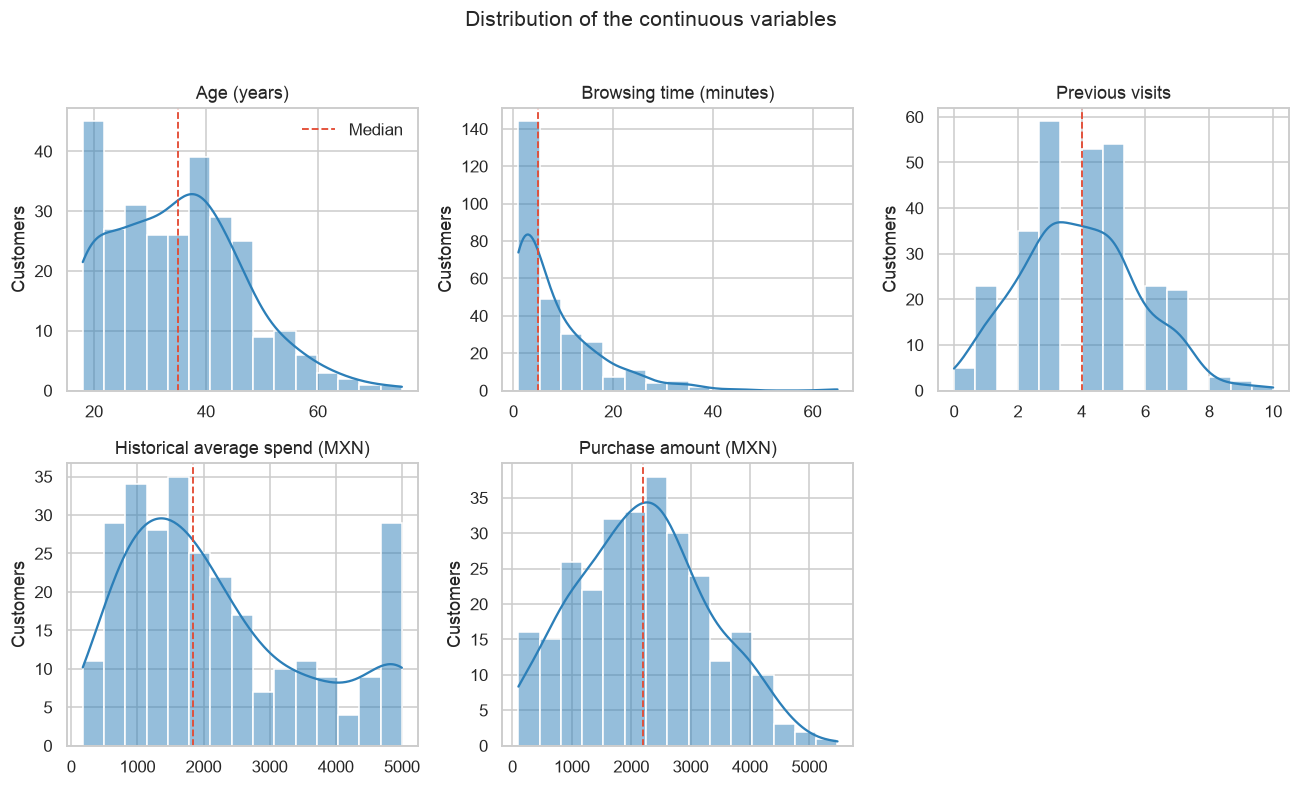

Skewness
edad                           0.498
tiempo_navegacion_min          2.123
visitas_previas                0.258
gasto_historico_promedio_mxn   0.729
monto_compra_mxn               0.189


In [3]:
labels = {
    "edad": "Age (years)",
    "tiempo_navegacion_min": "Browsing time (minutes)",
    "visitas_previas": "Previous visits",
    "gasto_historico_promedio_mxn": "Historical average spend (MXN)",
    "monto_compra_mxn": "Purchase amount (MXN)",
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for axis, column in zip(axes.flat, numeric_cols):
    sns.histplot(df[column], bins=15, kde=True, ax=axis, color="#2c7fb8")
    axis.axvline(df[column].median(), color="#e34a33", linestyle="--", linewidth=1.2, label="Median")
    axis.set_title(labels[column])
    axis.set_xlabel("")
    axis.set_ylabel("Customers")
axes.flat[-1].axis("off")
axes.flat[0].legend(frameon=False)
fig.suptitle("Distribution of the continuous variables", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

print("Skewness")
print(df[numeric_cols].skew().round(3).to_string())

#### Histogram interpretation

Purchase amount is the shape that matters most. It is close to symmetric (skewness = 0.19). The mean is about **2,195 MXN** and the median is about **2,199 MXN**, so a few extreme tickets do not pull the center. The spread is wide: the standard deviation is about **1,110 MXN**, and the range is 100 to 5,474 MXN. Customers do not cluster around one typical basket.

Age is mildly right-skewed (0.50). Most customers are young adults. The center is about 35 years, and the range is 18 to 75.

Browsing time is strongly right-skewed (2.12). The median session is only **5 minutes**, while the mean is about 8 minutes because a few sessions last 30 to 65 minutes. Most purchases happen after a short visit.

Previous visits are fairly symmetric (skewness = 0.26), from 0 to 10, with a mean near 4. Customers in this file are not heavy repeat visitors.

Historical average spend is right-skewed (0.73). The median (about 1,841 MXN) is below the mean (about 2,221 MXN). The spike at the right edge matches the 5,000 MXN cap found in cleaning.

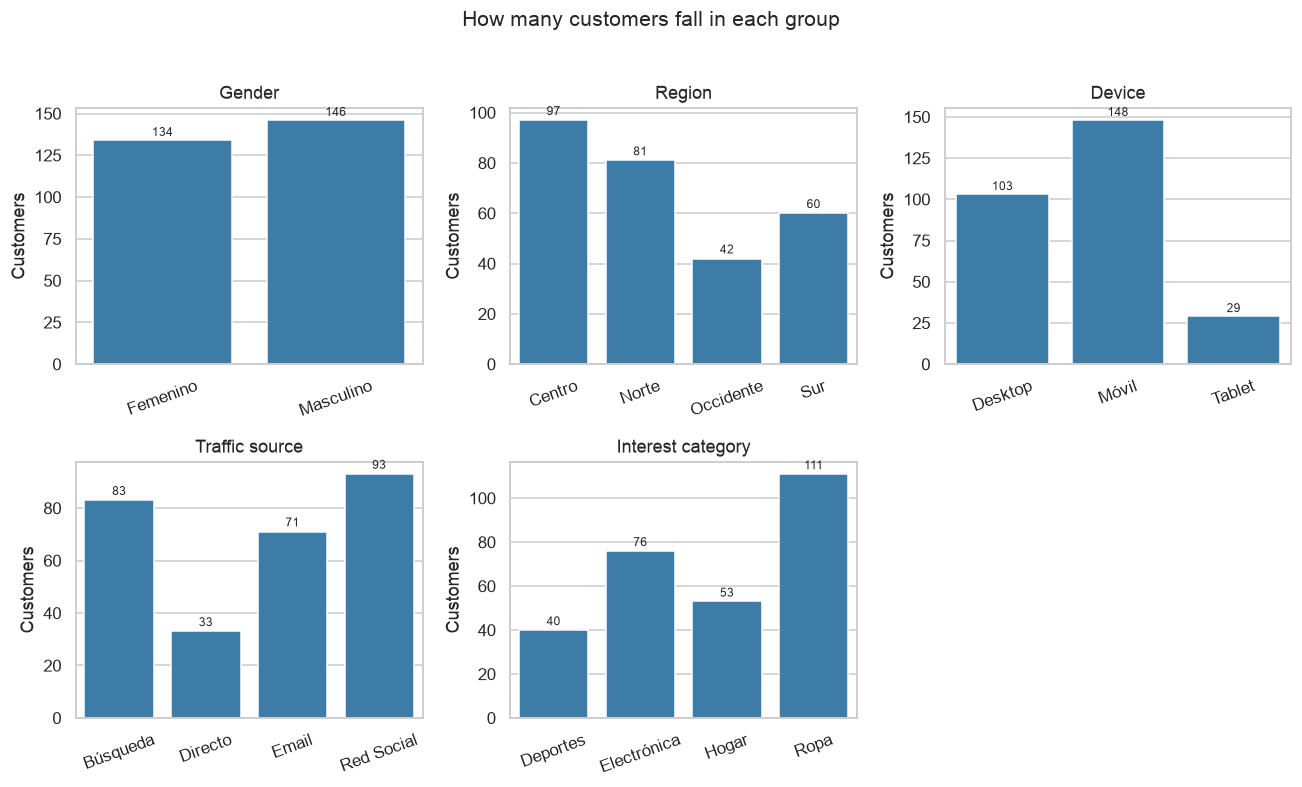

In [4]:
cat_orders = {
    "genero": gender_order,
    "region": region_order,
    "dispositivo": device_order,
    "fuente_trafico": traffic_order,
    "categoria_interes": category_order,
}
cat_titles = {
    "genero": "Gender",
    "region": "Region",
    "dispositivo": "Device",
    "fuente_trafico": "Traffic source",
    "categoria_interes": "Interest category",
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for axis, column in zip(axes.flat, categorical_cols):
    counts = df[column].value_counts().reindex(cat_orders[column])
    sns.barplot(x=counts.index, y=counts.values, ax=axis, color="#2c7fb8")
    axis.set_title(cat_titles[column])
    axis.set_xlabel("")
    axis.set_ylabel("Customers")
    axis.tick_params(axis="x", rotation=20)
    for patch, value in zip(axis.patches, counts.values):
        axis.text(patch.get_x() + patch.get_width() / 2, patch.get_height() + 1, str(int(value)), ha="center", va="bottom", fontsize=8)
axes.flat[-1].axis("off")
fig.suptitle("How many customers fall in each group", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

#### Bar-chart interpretation (frequency)

The sample is not balanced, and that will matter for the ANOVA cell sizes.

- **Gender** is almost even: 146 men and 134 women.
- **Region** is uneven. Center has 97 customers, North 81, South 60, and West only 42. West estimates will be less precise.
- **Device** is dominated by mobile (148), then desktop (103). Tablet has only 29 customers, so a tablet effect will be harder to detect.
- **Traffic source:** Social 93, Search 83, Email 71, Direct 33. Direct is the smallest channel.
- **Interest category:** Clothing is the largest group (111), then Electronics (76), Home (53), and Sports (40).

Frequency is not the same as value. A large group can still be a low-ticket group. The next figure shows the average purchase in each group.

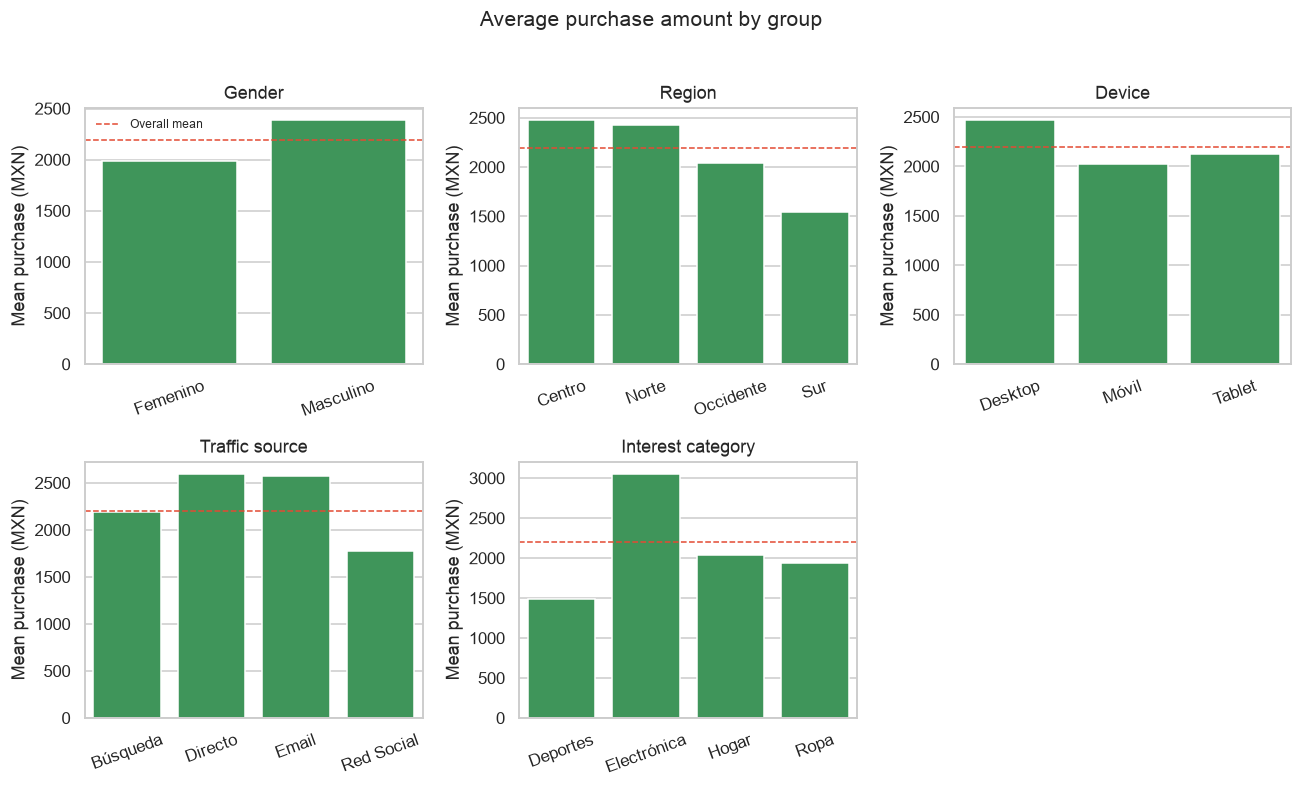

,factor,n,mean,median,std
Femenino,genero,134,"1,987.900","1,962.500","1,071.700"
Masculino,genero,146,"2,385.900","2,388.000","1,113.000"
Centro,region,97,"2,475.200","2,458.000","1,108.900"
Norte,region,81,"2,426.500","2,511.000","1,117.100"
Occidente,region,42,"2,041.600","2,082.500",947.500
Sur,region,60,"1,538.800","1,518.500",920.400
Desktop,dispositivo,103,"2,466.500","2,430.000","1,128.600"
Móvil,dispositivo,148,"2,020.300","1,977.000","1,056.800"
Tablet,dispositivo,29,"2,126.300","2,293.000","1,151.100"
Búsqueda,fuente_trafico,83,"2,188.500","2,158.000","1,044.900"


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for axis, column in zip(axes.flat, categorical_cols):
    means = (
        df.groupby(column)["monto_compra_mxn"]
        .mean()
        .reindex(cat_orders[column])
    )
    sns.barplot(x=means.index, y=means.values, ax=axis, color="#31a354")
    axis.axhline(df["monto_compra_mxn"].mean(), color="#e34a33", linestyle="--", linewidth=1, label="Overall mean")
    axis.set_title(cat_titles[column])
    axis.set_xlabel("")
    axis.set_ylabel("Mean purchase (MXN)")
    axis.tick_params(axis="x", rotation=20)
axes.flat[0].legend(frameon=False, fontsize=8)
axes.flat[-1].axis("off")
fig.suptitle("Average purchase amount by group", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

group_means = []
for column in categorical_cols:
    summary = (
        df.groupby(column)["monto_compra_mxn"]
        .agg(n="count", mean="mean", median="median", std="std")
        .reindex(cat_orders[column])
        .round(1)
    )
    summary.insert(0, "factor", column)
    group_means.append(summary)
display(pd.concat(group_means))

#### Average-purchase interpretation

The red line is the overall mean, about 2,195 MXN. Several gaps are large enough to test formally later.

- **Category** shows the biggest gap. Electronics averages about **3,052 MXN**. Sports averages about **1,494 MXN**. Home (about 2,043) and Clothing (about 1,935) sit in between, near the overall mean.
- **Region:** Center (about 2,475) and North (about 2,427) are close. West is lower (about 2,042). South is clearly lower (about **1,539**).
- **Traffic source:** Direct (about 2,594) and Email (about 2,575) are the high channels. Search is near the mean (about 2,189). Social is low (about **1,771**).
- **Gender:** Men average about 2,386 MXN and women about 1,988 MXN.
- **Device:** Desktop averages about 2,467 MXN, tablet about 2,126, and mobile about 2,020.

These are raw gaps. They do not yet control for the other factors, and they do not yet say whether the gap is larger than chance. That is the job of the regression and the ANOVA. The standard deviations inside every group are about 900 to 1,400 MXN, so the groups overlap a lot. A group can have a higher mean and still contain many small purchases.

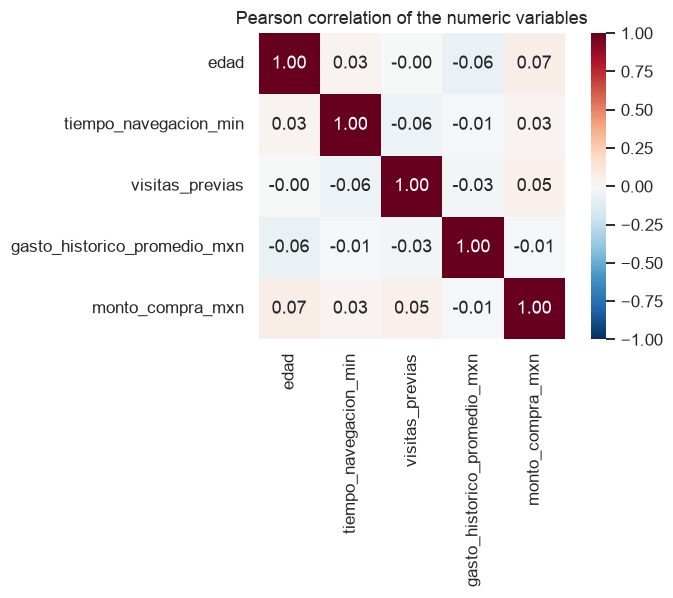

Correlation of each continuous predictor with purchase amount
edad                            0.069
tiempo_navegacion_min           0.028
visitas_previas                 0.050
gasto_historico_promedio_mxn   -0.011


In [6]:
corr = df[numeric_cols].corr(method="pearson")
fig, axis = plt.subplots(figsize=(7.2, 5.6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axis,
)
axis.set_title("Pearson correlation of the numeric variables")
fig.tight_layout()
plt.show()

print("Correlation of each continuous predictor with purchase amount")
print(corr["monto_compra_mxn"].drop("monto_compra_mxn").round(3).to_string())

#### Correlation interpretation

The numeric predictors are almost uncorrelated with each other and with purchase amount.

| Predictor | Correlation with purchase amount |
|---|---|
| Age | 0.07 |
| Browsing time | 0.03 |
| Previous visits | 0.05 |
| Historical average spend | −0.01 |

The largest absolute correlation is 0.07. In practical terms, knowing a customer's age, session length, visit count, or past average spend tells us almost nothing about **this** purchase, if we look only at a straight-line association.

Correlations among the predictors are also near zero (all well below 0.10). That is a good sign for regression: these four columns are not copies of each other.

This matrix cannot show the categorical factors. A correlation needs numbers. The bar charts already suggest that category, region, and traffic source move the average ticket. The regression will test those factors with dummy variables, together with the four numeric predictors.

## 3. Multiple linear regression (48%)

### 3.1 Problem description (3%)

**Business question.** Which factors predict how much a customer spends, and can we reliably predict spending for new customers?

The regression answers that question in two steps.

1. It estimates one equation for purchase amount. The equation includes the four numeric predictors and dummy variables for gender, region, device, traffic source, and interest category. Each coefficient is the change in expected purchase amount when that factor changes and the other factors stay fixed.
2. It is trained on 80% of the customers and then scored on the other 20%, which the model does not see. The holdout score tells Operations whether the equation is useful for a new customer, not only for the customers used to build it.

A significant coefficient is a factor the company can prioritize. A non-significant coefficient is a factor that, in this sample, does not add information once the others are known. The error metrics (MAE, MAPE, RMSE) say how far a prediction typically lands from the real ticket.

The model is ordinary least squares:

`monto_compra_mxn ~ age + browsing time + previous visits + historical spend + gender + region + device + traffic source + interest category`

Statsmodels uses treatment coding. The reference level of each factor is the first level in alphabetical order:

- Gender: **Femenino**
- Region: **Centro**
- Device: **Desktop**
- Traffic source: **Búsqueda**
- Interest category: **Deportes**

A dummy coefficient is the difference versus that reference level, not versus the sample average.

In [7]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=RANDOM_STATE)
print(f"Training customers: {len(train_df)}")
print(f"Testing customers: {len(test_df)}")

formula = (
    "monto_compra_mxn ~ edad + tiempo_navegacion_min + visitas_previas + "
    "gasto_historico_promedio_mxn + C(genero) + C(region) + C(dispositivo) + "
    "C(fuente_trafico) + C(categoria_interes)"
)
model = smf.ols(formula, data=train_df).fit()
print(model.summary())

Training customers: 224
Testing customers: 56


                            OLS Regression Results                            
Dep. Variable:       monto_compra_mxn   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     11.63
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           2.78e-21
Time:                        19:11:57   Log-Likelihood:                -1808.9
No. Observations:                 224   AIC:                             3652.
Df Residuals:                     207   BIC:                             3710.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

### 3.2 F-test (4%)

The F-test asks whether the regression is useful as a whole.

- **H0:** All slope coefficients are zero. None of the predictors has a linear relationship with purchase amount. The model is no better than using the training mean for every customer.
- **Ha:** At least one slope coefficient is not zero. At least one predictor is linearly related to purchase amount.
- **α = 0.05.** Reject H0 if the p-value is below 0.05, which is the same rule as F observed > F critical.

In [8]:
f_critical = stats.f.ppf(1 - ALPHA, model.df_model, model.df_resid)
print(f"F statistic     = {model.fvalue:.3f}")
print(f"Degrees of freedom = ({int(model.df_model)}, {int(model.df_resid)})")
print(f"p-value         = {model.f_pvalue:.4g}")
print(f"F critical      = {f_critical:.3f} at alpha = {ALPHA}")
print("Decision: reject H0." if model.f_pvalue < ALPHA else "Decision: do not reject H0.")

F statistic     = 11.634
Degrees of freedom = (16, 207)
p-value         = 2.779e-21
F critical      = 1.693 at alpha = 0.05
Decision: reject H0.


#### F-test interpretation

F = **11.63** with degrees of freedom **(16, 207)**. The critical value at 5% is about **1.69**. The observed F is far above that critical value, and the p-value is about **2.8 × 10⁻²¹**.

**Reject H0.** The model as a whole is statistically significant. At least one predictor is related to purchase amount. Using the regression is better than predicting every training customer with the training average.

The F-test does not say *which* factor matters, and it does not say the predictions are accurate. Those questions are the coefficient tests and the holdout errors below.

### 3.3 Significance and coefficient interpretation (13%)

For **each** slope βj the hypotheses are the same:

- **H0:** βj = 0. After the other predictors are in the model, this variable has no linear association with purchase amount.
- **Ha:** βj ≠ 0. After the other predictors are in the model, this variable still has a linear association with purchase amount.
- **α = 0.05.** Reject H0 when the p-value is below 0.05.

The intercept is the expected purchase when every numeric predictor is 0 and every factor is at its reference level. Age 0 and historical spend 0 are outside the data, so the intercept is a mathematical anchor, not a real customer. The slopes are the quantities Operations should read.

In [9]:
coef_table = pd.DataFrame(
    {
        "coefficient_mxn": model.params,
        "std_error": model.bse,
        "t": model.tvalues,
        "p_value": model.pvalues,
    }
)
coef_table["decision"] = np.where(coef_table["p_value"] < ALPHA, "Reject H0", "Do not reject H0")
coef_table = coef_table.round({"coefficient_mxn": 2, "std_error": 2, "t": 2, "p_value": 4})
display(coef_table)

exog = pd.DataFrame(model.model.exog, columns=model.model.exog_names).drop(columns=["Intercept"])
vif = pd.Series(
    [variance_inflation_factor(exog.values, i) for i in range(exog.shape[1])],
    index=exog.columns,
    name="VIF",
).sort_values(ascending=False)
print("\nVariance inflation factors (intercept excluded)")
display(vif.round(2).to_frame())
print(f"Condition number of the original design: {model.condition_number:,.0f}")

train_scaled = train_df.copy()
for column in predictor_numeric:
    train_scaled[column] = (train_scaled[column] - train_scaled[column].mean()) / train_scaled[column].std()
scaled_model = smf.ols(formula, data=train_scaled).fit()
print(f"Condition number after standardizing the four numeric predictors: {scaled_model.condition_number:.2f}")
print(f"R² is unchanged by that rescaling: {scaled_model.rsquared:.4f}")

,coefficient_mxn,std_error,t,p_value,decision
Intercept,"1,791.940",310.380,5.770,0.000,Reject H0
C(genero)[T.Masculino],331.220,109.250,3.030,0.003,Reject H0
C(region)[T.Norte],-37.280,137.510,-0.270,0.787,Do not reject H0
C(region)[T.Occidente],-166.500,177.650,-0.940,0.350,Do not reject H0
C(region)[T.Sur],-792.980,147.720,-5.370,0.000,Reject H0
C(dispositivo)[T.Móvil],-399.450,121.150,-3.300,0.001,Reject H0
C(dispositivo)[T.Tablet],-329.790,195.740,-1.680,0.093,Do not reject H0
C(fuente_trafico)[T.Directo],-117.180,192.990,-0.610,0.544,Do not reject H0
C(fuente_trafico)[T.Email],413.380,148.240,2.790,0.006,Reject H0
C(fuente_trafico)[T.Red Social],-498.680,142.970,-3.490,0.001,Reject H0



Variance inflation factors (intercept excluded)


,VIF
C(categoria_interes)[T.Ropa],2.520
C(categoria_interes)[T.Electrónica],2.290
C(categoria_interes)[T.Hogar],1.920
C(fuente_trafico)[T.Red Social],1.540
C(fuente_trafico)[T.Email],1.440
C(region)[T.Norte],1.310
C(region)[T.Sur],1.280
C(fuente_trafico)[T.Directo],1.260
C(dispositivo)[T.Móvil],1.250
C(region)[T.Occidente],1.220


Condition number of the original design: 17,784
Condition number after standardizing the four numeric predictors: 8.89
R² is unchanged by that rescaling: 0.4735


#### Which variables are significant?

**Reject H0** for these slopes. They stay associated with purchase amount after the other variables are held fixed.

| Term | Coefficient | p-value | Versus |
|---|---:|---:|---|
| Interest category: Electrónica | +1,512.81 MXN | < 0.001 | Deportes |
| Region: Sur | −792.98 MXN | < 0.001 | Centro |
| Traffic: Red Social | −498.68 MXN | 0.001 | Búsqueda |
| Device: Móvil | −399.45 MXN | 0.001 | Desktop |
| Gender: Masculino | +331.22 MXN | 0.003 | Femenino |
| Traffic: Email | +413.38 MXN | 0.006 | Búsqueda |
| Interest category: Hogar | +544.91 MXN | 0.007 | Deportes |
| Interest category: Ropa | +465.72 MXN | 0.008 | Deportes |

**Do not reject H0** for these slopes. In this sample they do not add a detectable linear effect once the other variables are included.

| Term | Coefficient | p-value |
|---|---:|---:|
| Device: Tablet | −329.79 MXN | 0.094 |
| Browsing time | −7.65 MXN per minute | 0.201 |
| Region: Occidente | −166.50 MXN | 0.350 |
| Previous visits | +28.68 MXN per visit | 0.330 |
| Traffic: Directo | −117.18 MXN | 0.544 |
| Historical average spend | −0.02 MXN per MXN | 0.621 |
| Region: Norte | −37.28 MXN | 0.787 |
| Age | +0.88 MXN per year | 0.849 |

Tablet is the closest miss (p = 0.094). The point estimate is about −330 MXN versus desktop, in the same direction as mobile, but the tablet group is small and the interval includes zero. It is not treated as a confirmed effect.

#### Business reading of the significant coefficients

All of these readings hold the other predictors fixed. They are not the raw group averages from the bar charts.

**Interest category is the strongest factor.** A customer interested in Electronics is expected to spend about **1,513 MXN more** than a customer interested in Sports. That is the largest shift in the model. Home is about **545 MXN** above Sports, and Clothing is about **466 MXN** above Sports. Merchandising and on-site priority should treat Electronics as the high-ticket category. Sports is the low-ticket reference. Pushing traffic into Sports, without a change in offer, will pull the average ticket down.

**The South spends less than the Center.** A customer in the South is expected to spend about **793 MXN less** than a similar customer in the Center. North is not different from the Center (about −37 MXN, p = 0.79). West is lower by about 167 MXN, but that gap is not significant (p = 0.35). The regional problem in this model is specifically the South, not a general "outside the Center" effect.

**Traffic source changes the ticket.** A customer from Social is expected to spend about **499 MXN less** than a similar customer from Search. A customer from Email is expected to spend about **413 MXN more** than a customer from Search. Direct is not distinguishable from Search (p = 0.54). If the goal is revenue per purchase, Email is the channel to protect and Social is the channel that brings cheaper baskets.

**Mobile spends less than desktop.** A mobile customer is expected to spend about **399 MXN less** than a desktop customer with the same profile. Operations should not read this as "mobile users are less valuable people." It can also mean the mobile path produces smaller baskets (checkout friction, harder comparison, different intent). It is still a real gap in this transaction.

**Men spend more than women in this sample.** The male coefficient is about **+331 MXN** versus women, with the other factors held fixed. This is a description of the current base, not a reason to exclude women. It says the mix of offers and campaigns is not producing the same ticket by gender.

**Age, browsing time, previous visits, and historical average spend do not predict this purchase.** One extra year of age moves the prediction by less than 1 MXN. One extra minute on the site moves it by about −8 MXN. One extra past visit moves it by about +29 MXN. One extra peso of historical average spend moves it by about −0.02 MXN. None of these clears 5%. Operations should not target high spenders with rules based on age, session length, visit count, or past average ticket. The 5,000 MXN cap on historical spend makes that coefficient even less useful as a fine-grained signal.

#### Note on the condition-number warning

The model summary warns that the condition number is large (about 17,800). That warning often means multicollinearity. Here it does not. Every variance inflation factor is below **2.6**. A VIF under 5 is not a collinearity problem. The four numeric predictors are also nearly uncorrelated. The large condition number comes from **scale**: historical spend is in the thousands, while the dummy variables are 0 or 1. After those four numeric columns are standardized, the condition number falls to about **8.9** and R² does not change. The coefficients in the table above stay in original MXN units so they can be read as pesos. They are not distorted by collinearity.

### 3.4 R² interpretation (5%)

- **R² = 0.473** on the training sample (224 customers).
- **Adjusted R² = 0.433**.

R² is the share of the variation in purchase amount that the fitted equation accounts for. The predictors explain about **47%** of the training variation. The other **53%** is individual behavior these columns do not capture: promotion response, exact product, income, urgency, and similar factors that are not in the file.

Adjusted R² applies a penalty for the 16 slopes. It falls from 47.3% to 43.3%, a drop of 4 points. That drop is moderate. The model is not an empty fit, and it is also not a fit that only looks good because it has many dummies. Part of the penalty is expected: age, browsing time, previous visits, historical spend, and several dummies were not significant. They use degrees of freedom without explaining much.

An R² near 0.45 is useful for **segment decisions**. It is not a tight forecast of one basket. Two customers with the same age, device, region, channel, and category can still differ by well over 1,000 MXN. The holdout section checks that this 47% is not only an in-sample result.

### 3.5 Assumptions testing (9%)

Inference from the t tests and the F test is trustworthy when four conditions hold. Each test below uses α = 0.05. The residuals are the training residuals, because that is the sample on which the coefficients were estimated.

1. **Linearity.** The mean of the errors is a straight-line function of the predictors.
2. **Independence.** The errors are independent of each other.
3. **Homoscedasticity.** The variance of the errors is constant.
4. **Normality.** The errors follow a normal distribution.

The plots give the visual check. The tests give the decision.

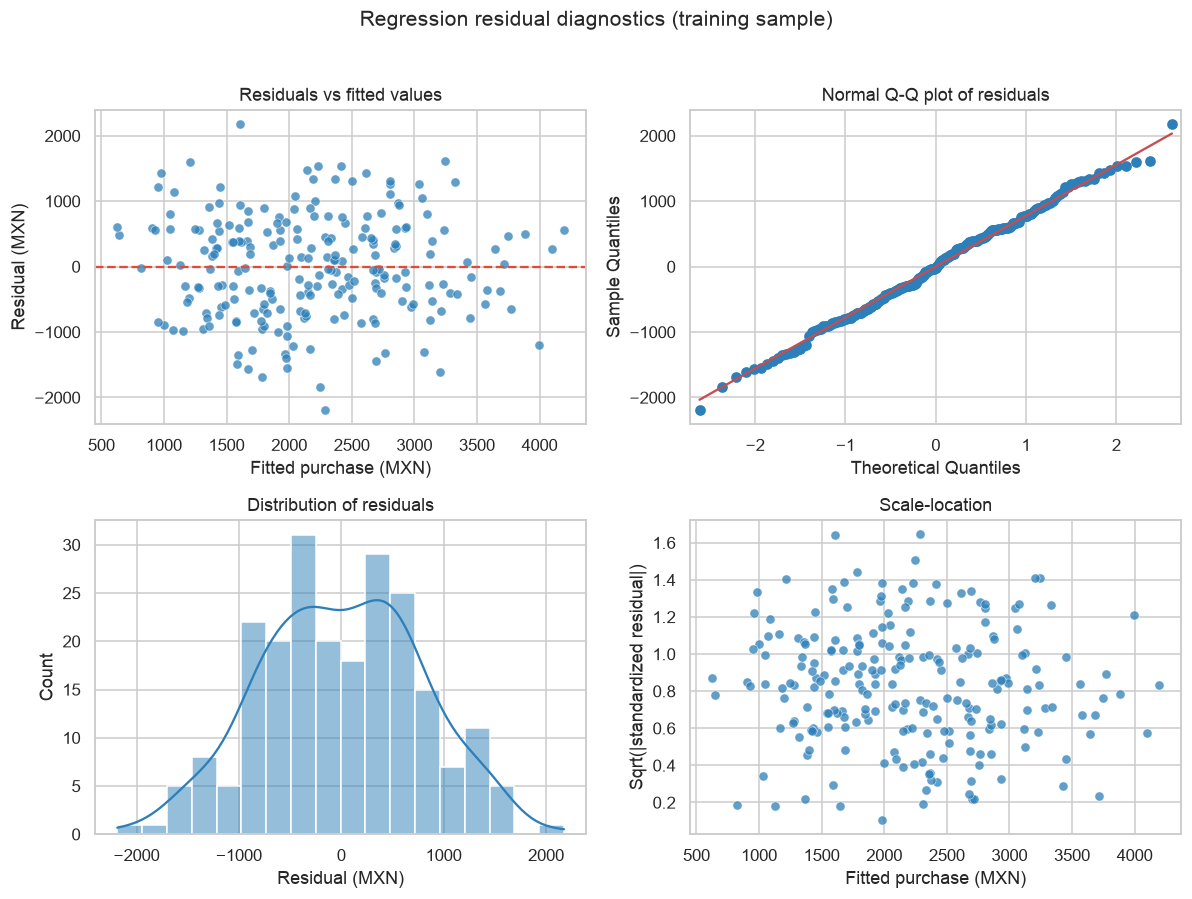

,assumption,test,statistic,p_value
0,Linearity,Rainbow,0.770,0.909
1,Independence,Durbin-Watson,1.965,NaN
2,Independence,Breusch-Godfrey (1 lag),0.067,0.796
3,Homoscedasticity,Breusch-Pagan,12.463,0.712
4,Normality,Shapiro-Wilk,0.996,0.766
5,Normality,Jarque-Bera,1.071,0.585


Residual skewness (Jarque-Bera) = -0.038
Residual kurtosis (Jarque-Bera) = 2.670


In [10]:
residuals = model.resid
fitted = model.fittedvalues
std_resid = residuals / residuals.std(ddof=int(model.df_model) + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].scatter(fitted, residuals, alpha=0.75, color="#2c7fb8", edgecolor="white", linewidth=0.4)
axes[0, 0].axhline(0, color="#e34a33", linestyle="--")
axes[0, 0].set_title("Residuals vs fitted values")
axes[0, 0].set_xlabel("Fitted purchase (MXN)")
axes[0, 0].set_ylabel("Residual (MXN)")

sm.qqplot(residuals, line="s", ax=axes[0, 1], markerfacecolor="#2c7fb8", markeredgecolor="#2c7fb8")
axes[0, 1].set_title("Normal Q-Q plot of residuals")

sns.histplot(residuals, bins=18, kde=True, ax=axes[1, 0], color="#2c7fb8")
axes[1, 0].set_title("Distribution of residuals")
axes[1, 0].set_xlabel("Residual (MXN)")

sqrt_abs = np.sqrt(np.abs(std_resid))
axes[1, 1].scatter(fitted, sqrt_abs, alpha=0.75, color="#2c7fb8", edgecolor="white", linewidth=0.4)
axes[1, 1].set_title("Scale-location")
axes[1, 1].set_xlabel("Fitted purchase (MXN)")
axes[1, 1].set_ylabel("Sqrt(|standardized residual|)")

fig.suptitle("Regression residual diagnostics (training sample)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

rainbow_stat, rainbow_p = linear_rainbow(model)
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuals, model.model.exog)
dw_stat = durbin_watson(residuals)
bg_lm, bg_lm_p, bg_f, bg_f_p = acorr_breusch_godfrey(model, nlags=1, result_object=False)
shapiro_stat, shapiro_p = stats.shapiro(residuals)
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(residuals)

assumption_tests = pd.DataFrame(
    [
        ["Linearity", "Rainbow", rainbow_stat, rainbow_p],
        ["Independence", "Durbin-Watson", dw_stat, np.nan],
        ["Independence", "Breusch-Godfrey (1 lag)", bg_lm, bg_lm_p],
        ["Homoscedasticity", "Breusch-Pagan", bp_lm, bp_lm_p],
        ["Normality", "Shapiro-Wilk", shapiro_stat, shapiro_p],
        ["Normality", "Jarque-Bera", jb_stat, jb_p],
    ],
    columns=["assumption", "test", "statistic", "p_value"],
)
display(assumption_tests.round(4))
print(f"Residual skewness (Jarque-Bera) = {jb_skew:.3f}")
print(f"Residual kurtosis (Jarque-Bera) = {jb_kurt:.3f}")

#### 1. Linearity

- **H0:** The linear specification is adequate. The mean response is linear in the predictors.
- **Ha:** The specification is not linear.
- **Test:** Rainbow test. Statistic = 0.77, **p = 0.91**.

**Do not reject H0.** There is no evidence of a curved relationship. The residual-versus-fitted plot does not show a U-shape or a slope. Residuals sit around zero across the fitted range. This result fits the data: the numeric predictors are weak, and the categorical effects are level shifts. Dummy variables represent level shifts without a curve.

#### 2. Independence

- **H0:** The errors are not autocorrelated (first-order correlation ρ = 0).
- **Ha:** The errors are autocorrelated (ρ ≠ 0).
- **Tests:** Durbin-Watson and Breusch-Godfrey with one lag.

Durbin-Watson = **1.965**. A value near 2 supports independence. Values toward 0 or 4 would mean positive or negative autocorrelation. Breusch-Godfrey p-value = **0.80**.

**Do not reject H0.** The residuals show no first-order autocorrelation. This file is a cross-section of customers, not a time series, and every customer id appears once. The design itself already supports independent rows. The tests agree.

#### 3. Homoscedasticity

- **H0:** The error variance is constant (homoscedasticity).
- **Ha:** The error variance is not constant (heteroscedasticity).
- **Test:** Breusch-Pagan. LM = 12.46, **p = 0.71**.

**Do not reject H0.** The spread of the residuals does not grow or shrink in a systematic way as the fitted purchase changes. The scale-location plot does not show a funnel. The usual standard errors in the coefficient table are appropriate. Robust standard errors are not required.

#### 4. Normality

- **H0:** The residuals come from a normal distribution.
- **Ha:** The residuals do not come from a normal distribution.
- **Tests:** Shapiro-Wilk and Jarque-Bera.

Shapiro-Wilk W = 0.996, **p = 0.77**. Jarque-Bera = 1.07, **p = 0.59**. Skewness is about −0.04 and kurtosis is about 2.67, close to the normal values of 0 and 3. The Q-Q points follow the reference line, including in the tails.

**Do not reject H0.** The residuals are compatible with a normal distribution. With 224 training rows, the t and F tests would be reasonably robust even with mild non-normality. Here the assumption actually holds, so the p-values in the coefficient table can be read directly.

**Assumption summary.** All four conditions are satisfied at α = 0.05. The significant coefficients are not an artifact of a broken residual pattern.

### 3.6 Purchase amount prediction (4%)

The fitted training equation is applied to the **56 customers in the test set**. Those rows were not used to estimate the coefficients. The plot compares predicted purchase amount with the actual purchase amount. The dashed line is perfect prediction: predicted = actual.

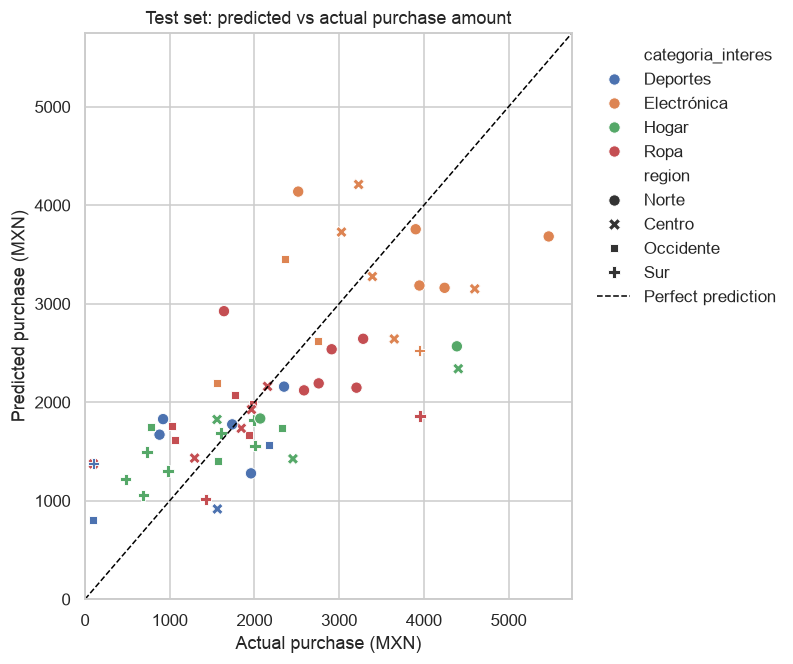

Correlation of predicted and actual = 0.710
Test-set R² = 0.495
Share of test predictions within 500 MXN  = 41.1%
Share of test predictions within 1,000 MXN = 73.2%

Largest absolute errors on the test set


,id_cliente,region,dispositivo,fuente_trafico,categoria_interes,monto_compra_mxn,predicted_mxn,error_mxn,abs_error_mxn
19,20,Sur,Desktop,Búsqueda,Ropa,3954,"1,860.500","2,093.500","2,093.500"
222,223,Centro,Desktop,Red Social,Hogar,4407,"2,340.400","2,066.600","2,066.600"
84,85,Norte,Desktop,Directo,Hogar,4390,"2,568.000","1,822.000","1,822.000"
33,34,Norte,Desktop,Directo,Electrónica,5474,"3,683.400","1,790.600","1,790.600"
75,76,Norte,Desktop,Email,Electrónica,2517,"4,138.800","-1,621.800","1,621.800"
79,80,Centro,Desktop,Directo,Electrónica,4601,"3,151.300","1,449.700","1,449.700"
245,246,Sur,Móvil,Búsqueda,Electrónica,3949,"2,524.900","1,424.100","1,424.100"
120,121,Norte,Desktop,Email,Ropa,1641,"2,924.600","-1,283.600","1,283.600"


In [11]:
test_pred = model.predict(test_df)
test_actual = test_df["monto_compra_mxn"]

fig, axis = plt.subplots(figsize=(7.4, 6.2))
sns.scatterplot(
    x=test_actual,
    y=test_pred,
    hue=test_df["categoria_interes"],
    hue_order=category_order,
    style=test_df["region"],
    s=55,
    ax=axis,
)
upper = max(test_actual.max(), test_pred.max()) * 1.05
axis.plot([0, upper], [0, upper], linestyle="--", color="black", linewidth=1, label="Perfect prediction")
axis.set_xlim(0, upper)
axis.set_ylim(0, upper)
axis.set_xlabel("Actual purchase (MXN)")
axis.set_ylabel("Predicted purchase (MXN)")
axis.set_title("Test set: predicted vs actual purchase amount")
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title=None)
fig.tight_layout()
plt.show()

pred_corr = np.corrcoef(test_actual, test_pred)[0, 1]
ss_res = np.sum((test_actual - test_pred) ** 2)
ss_tot = np.sum((test_actual - test_actual.mean()) ** 2)
test_r2 = 1 - ss_res / ss_tot
abs_error = np.abs(test_actual - test_pred)
print(f"Correlation of predicted and actual = {pred_corr:.3f}")
print(f"Test-set R² = {test_r2:.3f}")
print(f"Share of test predictions within 500 MXN  = {(abs_error <= 500).mean():.1%}")
print(f"Share of test predictions within 1,000 MXN = {(abs_error <= 1000).mean():.1%}")

error_table = test_df[
    ["id_cliente", "region", "dispositivo", "fuente_trafico", "categoria_interes", "monto_compra_mxn"]
].copy()
error_table["predicted_mxn"] = test_pred
error_table["error_mxn"] = error_table["monto_compra_mxn"] - error_table["predicted_mxn"]
error_table["abs_error_mxn"] = error_table["error_mxn"].abs()
print("\nLargest absolute errors on the test set")
display(error_table.nlargest(8, "abs_error_mxn").round(1))

#### Predicted-versus-actual interpretation

The cloud follows the diagonal, and the correlation between predicted and actual purchase is about **0.71**. Test-set R² is about **0.49**, close to the training R² of 0.47. The equation does not collapse on new customers. It has real signal.

It is not a close point forecast.

- About **41%** of test predictions fall within 500 MXN of the truth.
- About **73%** fall within 1,000 MXN.
- The vertical gaps are often several hundred pesos, and the worst gaps are about 1,400 to 2,100 MXN.

**Where the model fails most**

The largest misses are customers who do not behave like their segment.

- High tickets are often **under-predicted**. Customer 20 (South, Desktop, Search, Clothing) spent 3,954 MXN against a prediction near 1,860 MXN. The model expects a South clothing purchase from search to be modest. This one was not. Customer 34, the sample maximum (5,474 MXN, North, Desktop, Direct, Electronics), is predicted near 3,680 MXN. The model knows that profile should be high, but not high enough.
- Some "high" profiles are **over-predicted**. Customer 76 (North, Desktop, Email, Electronics) spent 2,517 MXN against a prediction near 4,140 MXN. Electronics plus email plus desktop is the expensive pattern, and this customer did not follow it.
- Points far **above** the dashed line are customers who spent less than their segment. Points far **below** it are customers who spent more.

Color by category shows that Electronics sits toward higher predictions, which matches the +1,513 MXN coefficient. Inside each category the scatter is still wide. The model is good at moving the forecast to the right segment average. It cannot see the product, the discount, or the intent that makes two Electronics customers differ by 2,000 MXN. That is why the continuous variables, which might have separated individuals, were not significant.

### 3.7 Error calculation (4%)

The three metrics use the same 56 test customers.

- **MAE** (mean absolute error) is the average size of the miss, in MXN. Every peso of error counts the same.
- **RMSE** (root mean squared error) is also in MXN. It squares the misses first, so a few large mistakes raise it more than they raise MAE.
- **MAPE** (mean absolute percentage error) is the average of |actual − predicted| / |actual|, in percent. It weights a miss by the size of the actual purchase.

In [12]:
mae = mean_absolute_error(test_actual, test_pred)
rmse = float(np.sqrt(mean_squared_error(test_actual, test_pred)))
ape = np.abs((test_actual - test_pred) / test_actual)
mape = float(ape.mean() * 100)
median_ape = float(ape.median() * 100)
mape_at_least_1000 = float(ape[test_actual >= 1000].mean() * 100)
mean_ticket = float(test_actual.mean())

error_summary = pd.DataFrame(
    {
        "metric": ["MAE (MXN)", "RMSE (MXN)", "MAPE (%)", "Median APE (%)", "MAPE, actual ≥ 1,000 MXN (%)"],
        "value": [mae, rmse, mape, median_ape, mape_at_least_1000],
    }
)
display(error_summary.round(2))
print(f"Mean actual purchase on the test set = {mean_ticket:,.0f} MXN")
print(f"MAE as a share of that mean = {mae / mean_ticket:.1%}")
print(f"Test purchases below 1,000 MXN = {int((test_actual < 1000).sum())} of {len(test_actual)}")

,metric,value
0,MAE (MXN),699.050
1,RMSE (MXN),880.920
2,MAPE (%),90.770
3,Median APE (%),28.350
4,"MAPE, actual ≥ 1,000 MXN (%)",25.500


Mean actual purchase on the test set = 2,238 MXN
MAE as a share of that mean = 31.2%
Test purchases below 1,000 MXN = 10 of 56


#### Error interpretation

**MAE ≈ 699 MXN.** On a typical new customer, the prediction misses the real purchase by about 700 pesos. The mean test purchase is about 2,240 MXN, so the typical miss is about **31% of the average ticket**. That is too wide for setting a price or promising a basket size. It is narrow enough to separate a low segment from a high segment, because those segments differ by 500 to 1,500 MXN.

**RMSE ≈ 881 MXN.** RMSE is about 180 MXN higher than MAE. The gap exists because the largest misses, around 1,500 to 2,100 MXN, are squared. The model’s usual error is closer to the MAE. The business risk is the occasional customer who is nothing like the segment average.

**MAPE ≈ 91%.** Read this number with care. MAPE divides by the actual purchase. Eight purchases in the full file are exactly 100 MXN, and several test purchases are small. A 700 MXN miss on a 100 MXN purchase is a 700% error, and it dominates the average. The **median** absolute percentage error is about **28%**. On test purchases of at least 1,000 MXN, MAPE falls to about **25%**. The 91% figure says the model is a poor percentage forecast for very small baskets. It does not say the model has no ranking power. The scatter plot and the test R² of 0.49 are the better picture of that power.

Together, the three metrics say: use the model to **prioritize segments**, and do not use it to predict one order to the nearest hundred pesos.

### 3.8 Regression conclusion (6%)

**Which factors matter most?**

Interest category matters most, then region (the South), then traffic source, device, and gender.

1. **Electronics** adds about 1,513 MXN versus Sports. Home adds about 545 MXN and Clothing about 466 MXN, both versus Sports.
2. **The South** spends about 793 MXN less than the Center. North and West are not significantly different from the Center.
3. **Social** spends about 499 MXN less than Search. **Email** spends about 413 MXN more than Search.
4. **Mobile** spends about 399 MXN less than desktop.
5. **Men** spend about 331 MXN more than women, with the other factors held fixed.

Age, browsing time, previous visits, and historical average spend do **not** predict this purchase. Tablet, Direct versus Search, and West versus Center are not significant at 5%.

**How good is the model?**

The F-test is highly significant (p ≈ 2.8 × 10⁻²¹). Training R² is 0.47 and adjusted R² is 0.43. On new customers, R² stays near 0.49 and the correlation of predicted with actual is 0.71. All four regression assumptions hold, so those tests are valid. The typical absolute error is about 700 MXN. That is good enough to rank segments and too wide to forecast one basket.

A concrete contrast, at the training-average age, browsing time, visits, and historical spend:

- Reference profile (woman, Center, desktop, Search, Sports): predicted purchase about **1,830 MXN**.
- High profile (man, Center, desktop, Email, Electronics): predicted purchase about **4,080 MXN**.
- The difference is about 2,250 MXN, and it comes from gender, Email, and Electronics. Category does most of the work.

**What Operations should do**

- Put commercial priority on **Electronics**, and do not expect Sports traffic to produce the same ticket.
- Treat **Email** as a high-value source and **Social** as a low-ticket source when the goal is revenue per purchase.
- Investigate the **South** gap of about 800 MXN before spending more to acquire the same kind of customer there. The regression says the gap remains after category, device, and channel are held fixed.
- Review the **mobile** path. Mobile baskets are about 400 MXN smaller than desktop baskets for otherwise similar customers. That can be a UX problem or a different shopper mission. Either way, it is large enough to measure.
- Stop using age, time on site, previous visits, or past average spend as screens for a large next purchase. They do not help.
- Do not deploy this equation as an individual pricing tool. Deploy it as a **segment** tool: who is likely to be in a high-ticket pattern, and which patterns are not worth the same acquisition cost.

In [13]:
profile_means = train_df[predictor_numeric].mean()
reference = {
    "edad": profile_means["edad"],
    "tiempo_navegacion_min": profile_means["tiempo_navegacion_min"],
    "visitas_previas": profile_means["visitas_previas"],
    "gasto_historico_promedio_mxn": profile_means["gasto_historico_promedio_mxn"],
    "genero": "Femenino",
    "region": "Centro",
    "dispositivo": "Desktop",
    "fuente_trafico": "Búsqueda",
    "categoria_interes": "Deportes",
}
high_value = reference | {
    "genero": "Masculino",
    "fuente_trafico": "Email",
    "categoria_interes": "Electrónica",
}
profiles = pd.DataFrame([reference, high_value], index=["Reference profile", "High-ticket profile"])
profiles["predicted_purchase_mxn"] = model.predict(profiles)
display(profiles.round(1))

,edad,tiempo_navegacion_min,visitas_previas,gasto_historico_promedio_mxn,genero,region,dispositivo,fuente_trafico,categoria_interes,predicted_purchase_mxn
Reference profile,35.200,8.400,3.900,"2,228.500",Femenino,Centro,Desktop,Búsqueda,Deportes,"1,826.400"
High-ticket profile,35.200,8.400,3.900,"2,228.500",Masculino,Centro,Desktop,Email,Electrónica,"4,083.800"


## 4. ANOVA (36%)

### 4.1 Problem description (4%)

**Business question.** Do customer groups really spend different amounts, or is the difference just random variation?

The bar charts show gaps: the South looks cheaper, Social looks cheaper, men look higher, desktop looks higher, Electronics looks much higher. A gap in a sample can appear even when every group has the same true mean. ANOVA separates those two cases.

The formal model is a **two-way ANOVA with interaction** between **region** (4 levels: Center, North, West, South) and **traffic source** (4 levels: Search, Direct, Email, Social). These are the two factors Marketing and the regional teams can act on together. The question is not only "does region matter?" and "does channel matter?" It is also "does the best channel depend on the region?"

The model is:

`purchase amount = region + traffic source + region × traffic source + error`

- A significant **region** effect means at least one region has a different mean purchase.
- A significant **traffic** effect means at least one channel has a different mean purchase.
- A significant **interaction** means the channel gap is not the same size in every region. A single national ranking of channels would then be incomplete.

Gender, device, and interest category are still part of the business question and of the exploration. They are tested with one-way ANOVA and Tukey so those groups are not ignored. They are not placed in the same interaction model: five factors would create hundreds of cells, and this file has only 280 rows. Interest category is already the main result of the regression. The ANOVA is reserved for the acquisition question (where the customer is, and how the customer arrived).

The ANOVA uses all 280 customers. Unlike the regression, it is a comparison of group means, not a forecast for a held-out customer.

### 4.2 Box plots (10%)

Each box shows the median (center line), the interquartile range (the box), and the whiskers. Points beyond the whiskers are far from that group's center. The dashed line is the overall mean purchase.

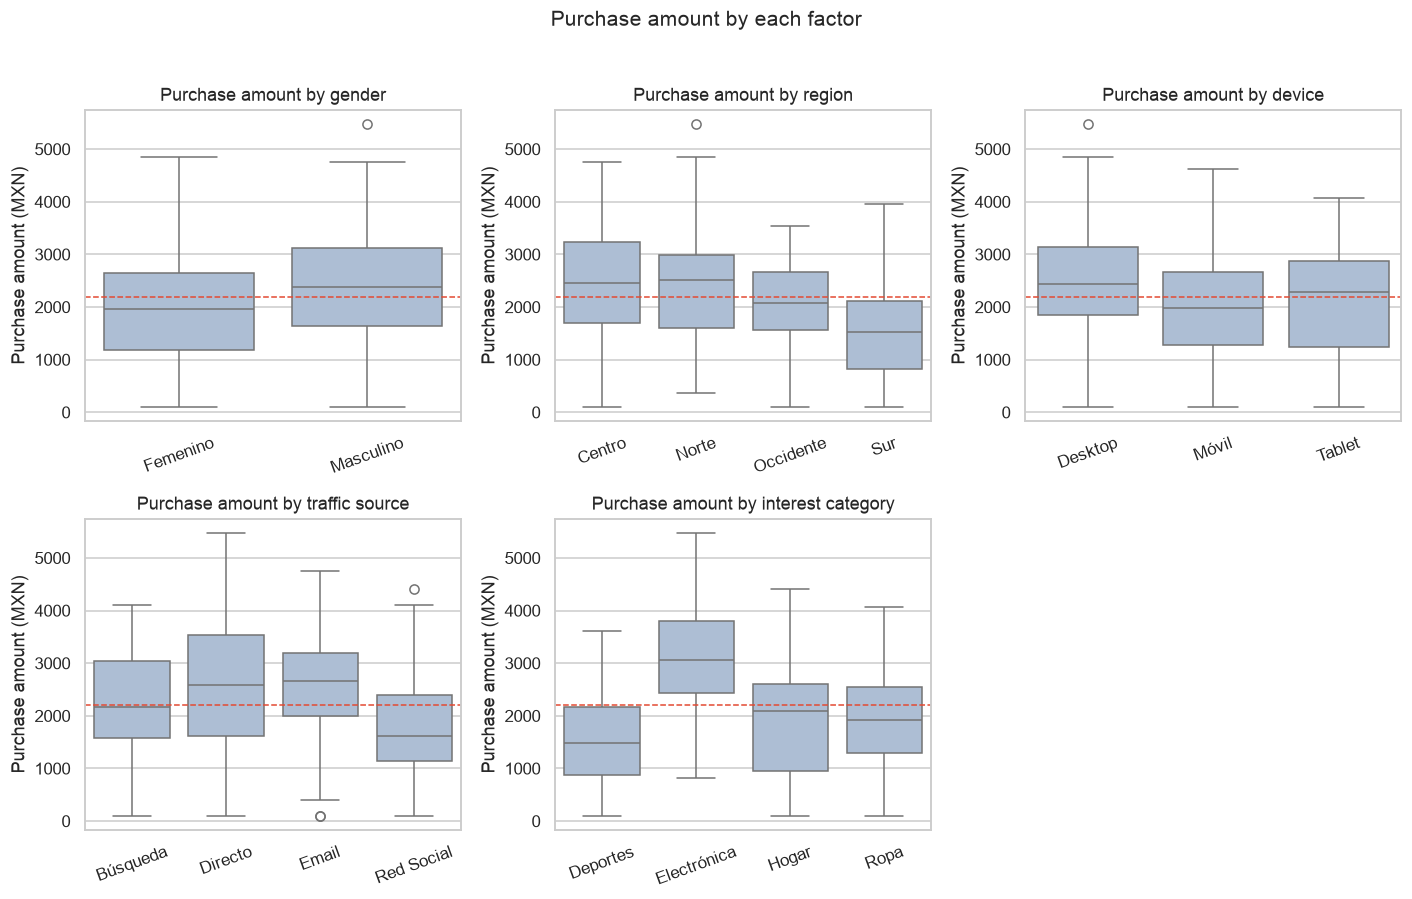

One-way ANOVA for each factor (supporting evidence for the box plots)


,factor,levels,F,p_value,decision
0,genero,2,9.257,0.003,Reject H0
1,region,4,11.710,0.000,Reject H0
2,dispositivo,3,5.121,0.006,Reject H0
3,fuente_trafico,4,9.537,0.000,Reject H0
4,categoria_interes,4,29.885,0.000,Reject H0


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for axis, column in zip(axes.flat, categorical_cols):
    sns.boxplot(
        data=df,
        x=column,
        y="monto_compra_mxn",
        order=cat_orders[column],
        ax=axis,
        color="#a6bddb",
        showfliers=True,
    )
    axis.axhline(df["monto_compra_mxn"].mean(), color="#e34a33", linestyle="--", linewidth=1)
    axis.set_title(f"Purchase amount by {cat_titles[column].lower()}")
    axis.set_xlabel("")
    axis.set_ylabel("Purchase amount (MXN)")
    axis.tick_params(axis="x", rotation=20)
axes.flat[-1].axis("off")
fig.suptitle("Purchase amount by each factor", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

print("One-way ANOVA for each factor (supporting evidence for the box plots)")
one_way_rows = []
for column in categorical_cols:
    groups = [group["monto_compra_mxn"].to_numpy() for _, group in df.groupby(column)]
    f_stat, p_value = stats.f_oneway(*groups)
    one_way_rows.append(
        {
            "factor": column,
            "levels": df[column].nunique(),
            "F": f_stat,
            "p_value": p_value,
            "decision": "Reject H0" if p_value < ALPHA else "Do not reject H0",
        }
    )
one_way = pd.DataFrame(one_way_rows)
display(one_way.round(4))

#### Box-plot interpretation

The boxes overlap in every panel. Group membership does not determine a customer's ticket. It shifts the center of the box. That matches the regression result: segments differ, and individuals inside a segment still vary by about 1,000 MXN.

- **Region.** The South box sits lower than the others. Its median is about 1,519 MXN, against about 2,458 in the Center and 2,511 in the North. The West median is about 2,083. The South is not only a lower mean; the whole middle of the distribution is lower.
- **Gender.** The male box sits above the female box. Medians are about 2,388 MXN and 1,963 MXN. The overlap is large.
- **Device.** The desktop box is the highest (median about 2,430). The mobile box is lower (median about 1,977). The tablet box is wide and based on only 29 customers, so its whiskers are less stable.
- **Traffic source.** The Social box is the low one (median about 1,617). Email (median about 2,661) and Direct (median about 2,586) are the high ones. Search sits near the overall mean.
- **Interest category.** Electronics is separated from the other three. Its median is about 3,062 MXN, and most of that box is above the overall mean. Sports is the low box (median about 1,486). Clothing and Home overlap each other.

The one-way F tests, shown under the figure, reject equal means for every factor at 5%: gender (p = 0.003), region (p < 0.001), device (p = 0.007), traffic source (p < 0.001), and category (p < 0.001). Category has the largest F, which agrees with the regression. These one-way tests do not control for the other factor and they do not test interaction. The model in the next section does both, for region and traffic source.

### 4.3 Model training (6%)

**Factors**

| Factor | Levels | Level names |
|---|---|---|
| `region` | 4 | Centro, Norte, Occidente, Sur |
| `fuente_trafico` | 4 | Búsqueda, Directo, Email, Red Social |

The interaction `region × fuente_trafico` has 4 × 4 = **16 cells**. The model is trained on all 280 rows with ordinary least squares, which for balanced or unbalanced group designs is the ANOVA decomposition. Sum contrasts (deviation coding) are used so that a Type III test of each main effect is well defined when the interaction is in the model.

Type III sums of squares test each term while the other terms, including the interaction, remain in the model. That is the right table once an interaction is part of the specification.

Customers in each region × traffic-source cell


fuente_trafico,Búsqueda,Directo,Email,Red Social
region,,,,
Centro,32,10,23,32
Norte,21,12,25,23
Occidente,9,5,8,20
Sur,21,6,15,18


Smallest cell: 5


,sum_sq,df,F,PR(>F)
Intercept,"1,008,008,237.651",1.000,"1,036.558",0.000
"C(region, Sum)","41,197,069.109",3.000,14.121,0.000
"C(fuente_trafico, Sum)","24,996,085.501",3.000,8.568,0.000
"C(region, Sum):C(fuente_trafico, Sum)","17,191,041.614",9.000,1.964,0.044
Residual,"256,728,701.199",264.000,NaN,NaN


ANOVA model R² = 0.253


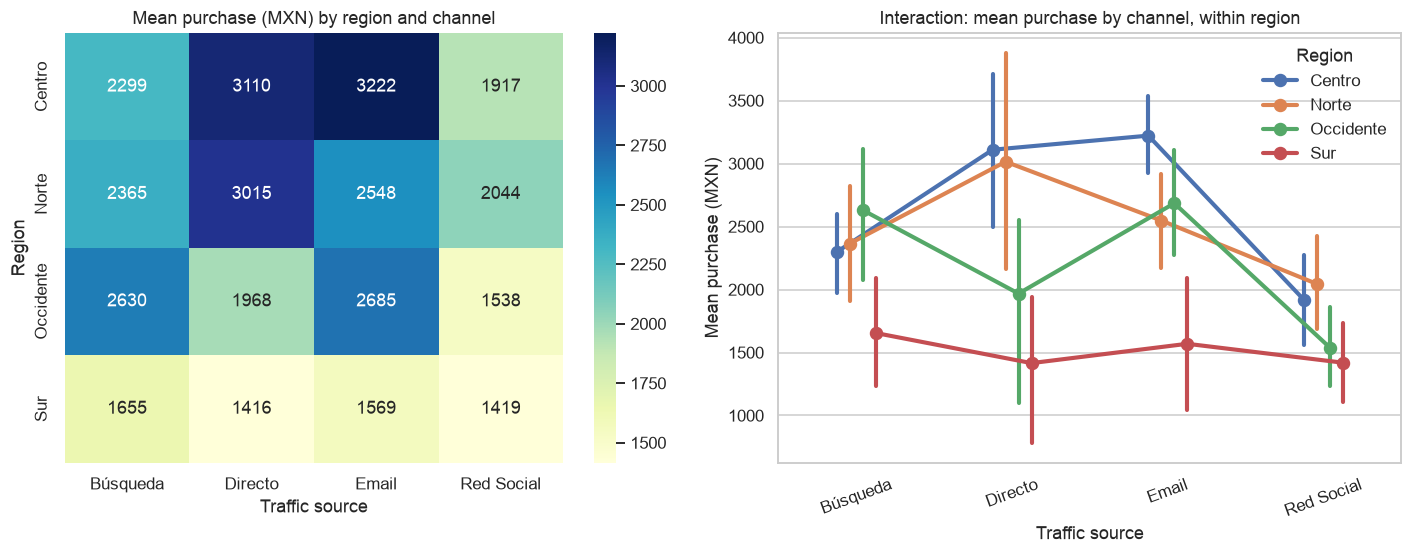

In [15]:
cell_counts = pd.crosstab(df["region"], df["fuente_trafico"]).reindex(index=region_order, columns=traffic_order)
print("Customers in each region × traffic-source cell")
display(cell_counts)
print("Smallest cell:", int(cell_counts.min().min()))

anova_formula = "monto_compra_mxn ~ C(region, Sum) * C(fuente_trafico, Sum)"
anova_model = smf.ols(anova_formula, data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=3)
display(anova_table.round(4))
print(f"ANOVA model R² = {anova_model.rsquared:.3f}")

cell_means = (
    df.pivot_table(
        index="region",
        columns="fuente_trafico",
        values="monto_compra_mxn",
        aggfunc="mean",
    )
    .reindex(index=region_order, columns=traffic_order)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
sns.heatmap(cell_means, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Mean purchase (MXN) by region and channel")
axes[0].set_xlabel("Traffic source")
axes[0].set_ylabel("Region")

sns.pointplot(
    data=df,
    x="fuente_trafico",
    y="monto_compra_mxn",
    hue="region",
    order=traffic_order,
    hue_order=region_order,
    errorbar=("ci", 95),
    dodge=0.25,
    ax=axes[1],
)
axes[1].set_title("Interaction: mean purchase by channel, within region")
axes[1].set_xlabel("Traffic source")
axes[1].set_ylabel("Mean purchase (MXN)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Region", frameon=False)
fig.tight_layout()
plt.show()

### 4.4 Results interpretation (8%)

There are three tests. Each uses α = 0.05.

**Region (main effect)**

- **H0:** The four regions have the same mean purchase amount, after traffic source and the interaction are accounted for.
- **Ha:** At least one region mean is different.

**Traffic source (main effect)**

- **H0:** The four traffic sources have the same mean purchase amount, after region and the interaction are accounted for.
- **Ha:** At least one traffic-source mean is different.

**Interaction**

- **H0:** There is no interaction. The difference between traffic sources is the same in every region.
- **Ha:** There is an interaction. The difference between traffic sources depends on the region.

#### Decisions

| Effect | F | p-value | Decision |
|---|---:|---:|---|
| Region | 14.12 | < 0.001 | Reject H0 |
| Traffic source | 8.57 | < 0.001 | Reject H0 |
| Region × traffic source | 1.96 | 0.044 | Reject H0 |

All three effects are significant.

Region and traffic source both shift purchase amount. The interaction is significant as well, but it is the weakest of the three (p = 0.044, just under 5%). The channel ranking is not perfectly constant across regions. It is also not a completely different business in each region.

The cell means make the pattern concrete:

- **Center + Email** averages about **3,222 MXN**, and **Center + Direct** about **3,110 MXN**. These are the high cells.
- **North + Direct** is also high, about **3,015 MXN**. North + Email is lower than Center + Email (about 2,548 MXN). The email advantage is clearest in the Center. That is the interaction.
- **Social is low in every region**, and lowest in the West (about 1,538 MXN) and the South (about 1,419 MXN).
- **The South is low on every channel** (about 1,416 to 1,655 MXN). In the South, Email and Direct do not reproduce the premium they have in the Center. The lines in the interaction plot for the South stay flat and below the other regions.

The ANOVA R² is about **0.25**. Region and channel, even with their interaction, explain less of the ticket than the regression did, because the regression also includes category, device, and gender. That is expected. This model answers a narrower question.

The main-effect tests say the groups differ. They do not say *which* pair differs. That is the Tukey test. Because the interaction is significant, pairwise tests on the 16 cells are reported together with the pairwise tests of the two factors.

### 4.5 Assumptions testing (12%)

The two ANOVA assumptions tested here are:

1. **Normality** of the model residuals.
2. **Homogeneity of variances** across the 16 region × channel cells.

Independence is supported by the design: one row per customer, and customers are not repeated measures. It is not given a separate hypothesis test in this section. Both tests use α = 0.05.

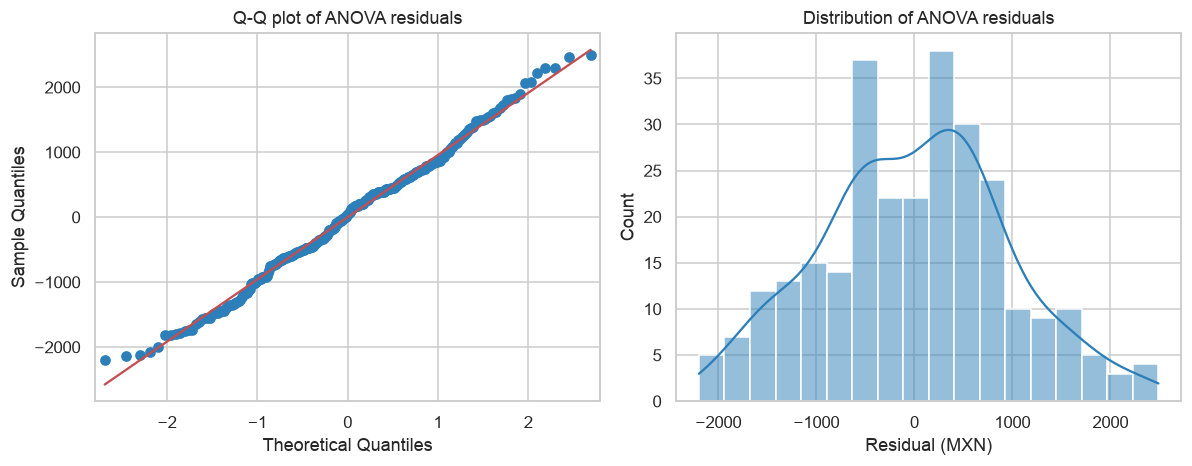

,assumption,test,statistic,p_value
0,Normality,Shapiro-Wilk on residuals,0.993,0.207
1,Equal variances,Levene (median) across 16 cells,1.644,0.063


Decision, normality: Do not reject H0
Decision, equal variances: Do not reject H0


In [16]:
anova_resid = anova_model.resid
shapiro_w, shapiro_p = stats.shapiro(anova_resid)

df = df.copy()
df["region_channel"] = df["region"] + " | " + df["fuente_trafico"]
cell_groups = [group["monto_compra_mxn"].to_numpy() for _, group in df.groupby("region_channel")]
levene_w, levene_p = stats.levene(*cell_groups, center="median")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
sm.qqplot(anova_resid, line="s", ax=axes[0], markerfacecolor="#2c7fb8", markeredgecolor="#2c7fb8")
axes[0].set_title("Q-Q plot of ANOVA residuals")
sns.histplot(anova_resid, bins=18, kde=True, ax=axes[1], color="#2c7fb8")
axes[1].set_title("Distribution of ANOVA residuals")
axes[1].set_xlabel("Residual (MXN)")
fig.tight_layout()
plt.show()

anova_assumptions = pd.DataFrame(
    [
        ["Normality", "Shapiro-Wilk on residuals", shapiro_w, shapiro_p],
        ["Equal variances", "Levene (median) across 16 cells", levene_w, levene_p],
    ],
    columns=["assumption", "test", "statistic", "p_value"],
)
display(anova_assumptions.round(4))
print("Decision, normality:", "Reject H0" if shapiro_p < ALPHA else "Do not reject H0")
print("Decision, equal variances:", "Reject H0" if levene_p < ALPHA else "Do not reject H0")

#### 1. Normality

- **H0:** The ANOVA residuals follow a normal distribution.
- **Ha:** The ANOVA residuals do not follow a normal distribution.
- **Test:** Shapiro-Wilk. W = 0.993, **p = 0.21**.

**Do not reject H0.** The residuals are compatible with normality. The Q-Q plot follows the reference line, and the histogram is roughly bell-shaped with no strong skew. The F tests are not being driven by a badly skewed error.

Within-cell normality tests are not used as the decision. Several cells have only 5 or 6 customers (West × Direct has 5, South × Direct has 6). A Shapiro test on five points has very little power. The residual test uses all 280 errors from the fitted model, which is the relevant check for the F statistic.

#### 2. Homogeneity of variances

- **H0:** Every region × traffic-source cell has the same variance of purchase amount.
- **Ha:** At least one cell has a different variance.
- **Test:** Levene’s test, centered at the median (robust to outliers). W = 1.64, **p = 0.063**.

**Do not reject H0** at 5%. The equal-variance assumption is acceptable, so the standard ANOVA F tests and the Tukey procedure remain appropriate.

The result is close to the line. p = 0.063 is not a comfortable pass. Direct has a larger raw standard deviation than Social in the exploration (about 1,371 versus 939). The practical reading is: variances are similar enough to keep the ANOVA, and they are not identical. The South and Social conclusions below are large mean gaps, not borderline ones, so a mild variance difference would not create them. The smallest cells should still be read with less confidence, because a mean based on 5 customers is noisy even when the variance test passes.

**Assumption summary.** Both assumptions hold at α = 0.05. Normality is comfortable. Equal variance is acceptable and close to the threshold.

### 4.6 Tukey test (12%)

ANOVA rejected equal means. Tukey’s HSD then tests every pair, with a family-wise error rate of 5%. A pair is reported as different only when Tukey rejects that pair.

- **H0 for a pair:** The two groups have the same mean purchase amount.
- **Ha for a pair:** The two groups have different mean purchase amounts.

Three families are tested for the trained model: the 4 regions, the 4 traffic sources, and the 16 region × channel cells. Gender, device, and interest category are added because the business question and the box plots raise those comparisons. Each `reject = True` row is a pair whose means differ after the multiple-comparison correction.

In [17]:
def tukey_table(factor: str) -> pd.DataFrame:
    tukey = pairwise_tukeyhsd(df["monto_compra_mxn"], df[factor], alpha=ALPHA)
    table = pd.DataFrame(tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    table.insert(0, "factor", factor)
    return table


tukey_region = tukey_table("region")
tukey_traffic = tukey_table("fuente_trafico")
tukey_cells = tukey_table("region_channel")
tukey_gender = tukey_table("genero")
tukey_device = tukey_table("dispositivo")
tukey_category = tukey_table("categoria_interes")

print("Region pairs")
display(tukey_region.round(3))
print("Traffic-source pairs")
display(tukey_traffic.round(3))
print("Significant region × channel pairs only")
significant_cells = tukey_cells[tukey_cells["reject"] == True].copy()
display(significant_cells.round(1))
print(f"Significant cell pairs: {len(significant_cells)} of {len(tukey_cells)}")

print("Additional pairs for the other factors named in the brief")
display(tukey_gender.round(3))
display(tukey_device.round(3))
display(tukey_category.round(3))

Region pairs


,factor,group1,group2,meandiff,p-adj,lower,upper,reject
0,region,Centro,Norte,-48.671,0.990,-457.426,360.084,False
1,region,Centro,Occidente,-433.570,0.117,-935.193,68.054,False
2,region,Centro,Sur,-936.398,0.000,"-1,382.434",-490.363,True
3,region,Norte,Occidente,-384.899,0.219,-901.275,131.478,False
4,region,Norte,Sur,-887.727,0.000,"-1,350.292",-425.162,True
5,region,Occidente,Sur,-502.829,0.084,"-1,049.191",43.534,False


Traffic-source pairs


,factor,group1,group2,meandiff,p-adj,lower,upper,reject
0,fuente_trafico,Búsqueda,Directo,405.542,0.250,-159.283,970.368,False
1,fuente_trafico,Búsqueda,Email,386.214,0.113,-57.469,829.898,False
2,fuente_trafico,Búsqueda,Red Social,-418.056,0.047,-832.491,-3.620,True
3,fuente_trafico,Directo,Email,-19.328,1.000,-597.573,558.916,False
4,fuente_trafico,Directo,Red Social,-823.598,0.001,"-1,379.718",-267.479,True
5,fuente_trafico,Email,Red Social,-804.270,0.000,"-1,236.816",-371.724,True


Significant region × channel pairs only


,factor,group1,group2,meandiff,p-adj,lower,upper,reject
24,region_channel,Centro | Directo,Occidente | Red Social,"-1,571.600",0.000,"-2,892.900",-250.200,True
25,region_channel,Centro | Directo,Sur | Búsqueda,"-1,454.700",0.000,"-2,765.500",-144.000,True
27,region_channel,Centro | Directo,Sur | Email,"-1,540.400",0.000,"-2,933.100",-147.600,True
28,region_channel,Centro | Directo,Sur | Red Social,"-1,690.400",0.000,"-3,035.900",-344.800,True
29,region_channel,Centro | Email,Centro | Red Social,"-1,304.700",0.000,"-2,237.300",-372.100,True
33,region_channel,Centro | Email,Norte | Red Social,"-1,177.800",0.000,"-2,183.800",-171.800,True
37,region_channel,Centro | Email,Occidente | Red Social,"-1,683.700",0.000,"-2,726.700",-640.600,True
38,region_channel,Centro | Email,Sur | Búsqueda,"-1,566.800",0.000,"-2,596.500",-537.100,True
39,region_channel,Centro | Email,Sur | Directo,"-1,805.800",0.000,"-3,369.700",-241.800,True
40,region_channel,Centro | Email,Sur | Email,"-1,652.500",0.000,"-2,784.700",-520.200,True


Significant cell pairs: 16 of 120
Additional pairs for the other factors named in the brief


,factor,group1,group2,meandiff,p-adj,lower,upper,reject
0,genero,Femenino,Masculino,397.997,0.003,140.488,655.506,True


,factor,group1,group2,meandiff,p-adj,lower,upper,reject
0,dispositivo,Desktop,Móvil,-446.212,0.005,-776.843,-115.581,True
1,dispositivo,Desktop,Tablet,-340.131,0.302,-881.789,201.528,False
2,dispositivo,Móvil,Tablet,106.081,0.882,-417.173,629.336,False


,factor,group1,group2,meandiff,p-adj,lower,upper,reject
0,categoria_interes,Deportes,Electrónica,"1,558.249",0.000,"1,068.909","2,047.588",True
1,categoria_interes,Deportes,Hogar,549.751,0.036,25.075,"1,074.428",True
2,categoria_interes,Deportes,Ropa,441.201,0.067,-20.771,903.172,False
3,categoria_interes,Electrónica,Hogar,"-1,008.497",0.000,"-1,456.797",-560.198,True
4,categoria_interes,Electrónica,Ropa,"-1,117.048",0.000,"-1,490.015",-744.081,True
5,categoria_interes,Hogar,Ropa,-108.551,0.908,-526.805,309.704,False


#### Which groups differ?

**Regions.** Two pairs differ.

- **South vs Center:** the South mean is about **936 MXN lower** (p < 0.001).
- **South vs North:** the South mean is about **888 MXN lower** (p < 0.001).

Center and North do not differ (p = 0.99). West does not differ from Center (p = 0.12), from North (p = 0.22), or from South (p = 0.08). The West-versus-South gap is about 503 MXN and is the closest non-significant pair. With only 42 customers in the West, that comparison is under-powered. The confirmed regional result is: **the South is below the Center and the North. The Center and the North are the same.**

**Traffic sources.** Social is the channel that differs. The other three do not differ from each other.

- **Social vs Search:** Social is about **418 MXN lower** (p = 0.047).
- **Social vs Email:** Social is about **804 MXN lower** (p < 0.001).
- **Social vs Direct:** Social is about **824 MXN lower** (p = 0.001).
- Search vs Email (p = 0.11), Search vs Direct (p = 0.25), and Email vs Direct (p ≈ 1) are not significant.

Search, Email, and Direct can be treated as one high-to-middle band. Social is the low band. The Email-versus-Search gap looks large in the Center cell means, but across all regions Tukey does not separate Email from Search. The email premium is regional, which is why the interaction matters.

**Region × channel cells.** Tukey finds **16 significant pairs out of 120**. They tell one story.

The high cells are **Center | Email**, **Center | Direct**, and **North | Direct**. The low cells are **every South channel**, plus **West | Social**, and Social in the Center and the North.

- Center | Email is higher than Center | Social (about 1,305 MXN), North | Social, West | Social, and all four South channels.
- Center | Direct and North | Direct are higher than West | Social and the South channels.
- North | Email is significantly higher only than South | Social. Its advantage is smaller than Center | Email.

No pair *inside* the South is significant. South | Search, South | Direct, South | Email, and South | Social are statistically the same low level. Buying a "better" channel does not repair the South gap in this sample.

**Gender, device, and category (additional Tukey tests)**

- **Gender:** Men spend about **398 MXN more** than women (p = 0.003). With two groups, this is the same comparison as the one-way test.
- **Device:** Desktop is about **446 MXN higher** than mobile (p = 0.005). Tablet does not differ from desktop (p = 0.30) or from mobile (p = 0.88). The tablet sample is too small to call tablet a third tier.
- **Category:** Electronics differs from all three other categories. It is about **1,558 MXN** above Sports, **1,008 MXN** above Home, and **1,117 MXN** above Clothing (all p < 0.001). Home is also about **550 MXN** above Sports (p = 0.036). Clothing vs Sports (p = 0.067) and Clothing vs Home (p = 0.91) are not significant. This agrees with the regression: Electronics is the high-ticket category, and Sports is the low one.

#### How confident are these pair calls?

Confidence is high for the large, well-sampled gaps: South vs Center, South vs North, Social vs Email, Social vs Direct, desktop vs mobile, men vs women, and Electronics vs the other categories. Those p-values are far below 5%, or the samples on both sides are large.

Confidence is lower for two kinds of result. The interaction itself is only just significant (p = 0.044). And any contrast that uses West | Direct (n = 5) or South | Direct (n = 6) has a wide interval. Those cells should not be the only reason for a budget move. The pattern that does *not* depend on the tiny cells is still clear: the South is low on the larger cells too (South | Search n = 21, South | Social n = 18, South | Email n = 15), and Center | Email (n = 23) is high.

### 4.7 ANOVA conclusion (4%)

**Do groups really spend different amounts?** Yes. The differences are not random variation.

The two-way model rejects equal means for region (p < 0.001), for traffic source (p < 0.001), and for their interaction (p = 0.044). Residual normality holds (Shapiro p = 0.21). Equal cell variances are acceptable (Levene p = 0.063). Tukey then names the pairs.

**Which groups differ?**

- The **South** spends about 900 MXN less than the Center and the North. That gap shows up on every channel. Center and North do not differ.
- **Social** spends less than Search, Email, and Direct. Search, Email, and Direct do not differ once all regions are pooled.
- The **interaction** says the high combination is specific: Email and Direct in the **Center**, and Direct in the **North**. Email does not create the same premium in the South. Social is weak everywhere, and especially weak in the West and the South.
- Supporting pairwise tests: **men** spend more than women, **desktop** spends more than mobile, and **Electronics** spends more than Home, Clothing, and Sports.

**What Marketing and the regional teams should do**

- Shift acquisition budget **from Social toward Email**, especially in the Center, where Email averages about 3,220 MXN against about 1,920 MXN for Social. Do not judge Social by click volume if the goal is revenue per purchase.
- Keep **Direct** as a valuable source in the Center and the North (means near 3,000 MXN). Do not expect that Direct premium in the South.
- Do not try to close the South gap by buying the same channels more aggressively. South means stay between about 1,400 and 1,660 MXN on every source, and Tukey finds no channel difference inside the South. The regional team should look at assortment, delivered price, shipping, and local demand before it increases media spend.
- Treat Center and North as the core high-ticket regions. Treat the West as uncertain: it is smaller, and its Social mean is low, but West vs Center is not significant.
- Use gender and device as secondary segments, not as the main media split. The desktop-versus-mobile gap (about 450 MXN) belongs with the Operations finding on the mobile path. The Electronics gap belongs with merchandising: sending any channel into Electronics will raise the ticket more than switching region inside the Center and the North.

**Confidence.** High for "South is lower" and "Social is lower than Email and Direct." Moderate for the interaction, because p = 0.044 and two cells have fewer than 10 customers. The action that depends on the tiny cells should wait. The action that does not — less Social, a South commercial review, and protection of Center email — is supported by the larger cells.

## 5. Joint answer for the company

The two methods agree, and they answer different decisions.

| Decision | Evidence | Action |
|---|---|---|
| What raises the ticket? | Regression: Electronics (+1,513 vs Sports), Email (+413 vs Search), male (+331), Home and Clothing above Sports | Prioritize Electronics. Prefer Email when the goal is revenue per order. |
| What lowers the ticket? | Regression and Tukey: South (about −800 to −900 vs Center), Social (about −500 vs Search), mobile (about −400 vs desktop) | Review the South offer. Do not pay Social the same acquisition cost as Email. Review the mobile path. |
| What should be ignored? | Age, browsing time, previous visits, historical average spend; Center vs North; Direct vs Search nationally | Do not build targeting rules on session length or past average spend. |
| Can we predict one new customer? | Test R² ≈ 0.49, MAE ≈ 700 MXN, assumptions hold | Predict the **segment**, not the exact pesos. |
| Does the best channel depend on the region? | Interaction p = 0.044. Center Email is the high cell. The South is flat and low. | A national channel ranking is not enough. Run the Email push in the Center and the North. Do not copy it into the South until the regional gap is understood. |

The regression is the tool for "which factors, holding the others fixed." The ANOVA is the tool for "which groups, and which combinations, are truly different." Used together, they tell Operations and Marketing to chase Electronics and Email in the Center and the North, and to stop treating the South gap and the Social gap as noise.